# 01 Data exploration and cleaning

CSE 4889 Machine Learning: Explainable Multi-Label Hate Speech Detection in Transliterated Bangla

In this notebook we load the BanTH dataset, check the labels, clean the text, and save the tables and charts for the dataset part of the report. The cleaned data is saved for the training notebook.

Note: the dataset contains real hateful comments, and some of them are printed below.

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports, paths and column names

We use the exact column names from BanTH. Text is the comment, Label is 1 for hate and 0 for not hate, and the 8 category columns are 0/1. The bangla and english columns come with the dataset. We keep them for reference but train only on Text.

In [2]:
import os
import re
import json
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

BASE = '/content/drive/MyDrive/ML_Project'
SEED = 42
NOTEBOOK_NAME = '01_data_exploration.ipynb'

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

RAW_DIR = os.path.join(BASE, 'data', 'raw')
PROC_DIR = os.path.join(BASE, 'data', 'processed')
FIG_DIR = os.path.join(BASE, 'results', 'figures')
TAB_DIR = os.path.join(BASE, 'results', 'tables')
REP_DIR = os.path.join(BASE, 'results', 'evaluation_reports')
ASSETS_PATH = os.path.join(BASE, 'results', 'ASSETS.md')
assert os.path.exists(ASSETS_PATH), 'Run 00_setup_drive_folders.ipynb first.'

TEXT_COL = 'Text'
HATE_COL = 'Label'
TARGET_COLS = ['Political', 'Religious', 'Gender', 'Personal Offense',
               'Abusive/Violence', 'Origin', 'Body Shaming', 'Misc']
EXPECTED_COLS = [TEXT_COL, HATE_COL] + TARGET_COLS + ['bangla', 'english']

pd.set_option('display.max_colwidth', 120)
print('Ready. Project root:', BASE)

Ready. Project root: /content/drive/MyDrive/ML_Project


## Helper functions

Each table is saved as a CSV and also as a LaTeX file for the report, and each saved file is added to ASSETS.md. We also set one plot style for all figures: small font for the two-column paper, 300 dpi, and no titles because the caption goes under the figure.

In [3]:
def save_table(df, name, tex_df=None, float_format='%.2f'):
    csv_path = os.path.join(TAB_DIR, f'{name}.csv')
    tex_path = os.path.join(TAB_DIR, f'{name}.tex')
    df.to_csv(csv_path, index=False)
    (df if tex_df is None else tex_df).to_latex(tex_path, index=False, escape=True,
                                                float_format=float_format)
    print('Saved:', csv_path)
    print('Saved:', tex_path)

def register_asset(asset_id, file_name, what, notebook, section, caption):
    row = f'| {asset_id} | {file_name} | {what} | {notebook} | {section} | {caption} |'
    with open(ASSETS_PATH, encoding='utf-8') as f:
        lines = f.read().splitlines()
    lines = [l for l in lines if not l.startswith(f'| {asset_id} |')]
    lines.append(row)
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print('Registered', asset_id, '->', file_name)

BLUE = '#2a78d6'
INK = '#0b0b0b'
MUTED = '#52514e'
plt.rcParams.update({
    'font.size': 8, 'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': '#e5e4e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})

## Load BanTH

We use the official train, validation and test splits so our results can be compared with the BanTH paper. The check stops the notebook if the split sizes are not 29,879 / 3,736 / 3,735.

In [4]:
dataset = load_dataset('aplycaebous/BanTH')
print(dataset)

splits = {
    'train': dataset['train'].to_pandas(),
    'validation': dataset['validation'].to_pandas(),
    'test': dataset['test'].to_pandas(),
}

EXPECTED_SIZES = {'train': 29879, 'validation': 3736, 'test': 3735}
for name, df in splits.items():
    assert len(df) == EXPECTED_SIZES[name], f'{name}: {len(df)} rows, expected {EXPECTED_SIZES[name]}'
    print(f'{name:<10} {len(df):>6,} rows')

README.md:   0%|          | 0.00/1.82k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/8.23M [00:00<?, ?B/s]

val.csv:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29879 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3736 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3735 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Text', 'Label', 'Political', 'Religious', 'Gender', 'Personal Offense', 'Abusive/Violence', 'Origin', 'Body Shaming', 'Misc', 'bangla', 'english'],
        num_rows: 29879
    })
    validation: Dataset({
        features: ['Text', 'Label', 'Political', 'Religious', 'Gender', 'Personal Offense', 'Abusive/Violence', 'Origin', 'Body Shaming', 'Misc', 'bangla', 'english'],
        num_rows: 3736
    })
    test: Dataset({
        features: ['Text', 'Label', 'Political', 'Religious', 'Gender', 'Personal Offense', 'Abusive/Violence', 'Origin', 'Body Shaming', 'Misc', 'bangla', 'english'],
        num_rows: 3735
    })
})
train      29,879 rows
validation  3,736 rows
test        3,735 rows


## Save a raw copy

We save the data as downloaded, before changing anything. Every comment also gets an ID like test_00017, so we can refer to the same comment later in the explanation and annotation parts.

In [5]:
for name, df in splits.items():
    df.insert(0, 'comment_id', [f'{name}_{i:05d}' for i in range(len(df))])
    path = os.path.join(RAW_DIR, f'banth_{name}.csv')
    df.to_csv(path, index=False, encoding='utf-8')
    print('Saved:', path)

train_df, val_df, test_df = splits['train'], splits['validation'], splits['test']

Saved: /content/drive/MyDrive/ML_Project/data/raw/banth_train.csv
Saved: /content/drive/MyDrive/ML_Project/data/raw/banth_validation.csv
Saved: /content/drive/MyDrive/ML_Project/data/raw/banth_test.csv


## Check columns and labels

We check that all columns are present, nothing is missing, and the labels are only 0 or 1.

In [6]:
for name, df in splits.items():
    missing_cols = [c for c in EXPECTED_COLS if c not in df.columns]
    assert not missing_cols, f'{name}: missing columns {missing_cols}'
    n_missing = int(df[EXPECTED_COLS].isnull().sum().sum())
    assert n_missing == 0, f'{name}: {n_missing} missing values'
    for col in [HATE_COL] + TARGET_COLS:
        values = set(df[col].unique())
        assert values <= {0, 1}, f'{name}.{col} has values {values}'
    print(f'{name:<10} OK: all columns present, no missing values, labels are 0/1')

print('\nColumn types (train):')
print(train_df.dtypes)

train      OK: all columns present, no missing values, labels are 0/1
validation OK: all columns present, no missing values, labels are 0/1
test       OK: all columns present, no missing values, labels are 0/1

Column types (train):
comment_id          object
Text                object
Label                int64
Political            int64
Religious            int64
Gender               int64
Personal Offense     int64
Abusive/Violence     int64
Origin               int64
Body Shaming         int64
Misc                 int64
bangla              object
english             object
dtype: object


## Do the hate label and the categories match?

A non-hate comment should have no category, and a hate comment should have at least one. We count the rows that don't follow this but don't remove them, so the splits stay the same as in the paper.

In [7]:
consistency = {}
for name, df in splits.items():
    df['num_categories'] = df[TARGET_COLS].sum(axis=1)
    nonhate_with_cat = int(((df[HATE_COL] == 0) & (df['num_categories'] > 0)).sum())
    hate_without_cat = int(((df[HATE_COL] == 1) & (df['num_categories'] == 0)).sum())
    consistency[name] = {'nonhate_with_category': nonhate_with_cat,
                         'hate_without_category': hate_without_cat}
    print(f'{name:<10} non-hate rows with a category: {nonhate_with_cat:>4} | '
          f'hate rows with no category: {hate_without_cat:>4}')

train      non-hate rows with a category:    0 | hate rows with no category:    0
validation non-hate rows with a category:    0 | hate rows with no category:    0
test       non-hate rows with a category:    0 | hate rows with no category:    0


## Text cleaning

We only remove URLs and extra spaces or line breaks. The cleaned text goes into a new clean_text column and the original is kept.

Things we keep on purpose:
- Spelling variation (for example hok/hook, vai/bhai). People write Bangla in English letters in many different ways, and this is the main difficulty we want the model to handle.
- Emoji and punctuation, because they often show the tone of a comment.
- Upper and lower case, since the tokenizer handles this.
- Stop words, because the model uses the whole sentence and the explanations should show the words people actually wrote.
- All rows, so the split sizes stay the same.

In [8]:
URL_RE = re.compile(r'http\S+|www\S+')
SPACE_RE = re.compile(r'\s+')

def clean_text(text):
    text = str(text)
    text = URL_RE.sub('', text)
    text = SPACE_RE.sub(' ', text).strip()
    return text

cleaning_stats = {}
for name, df in splits.items():
    raw = df[TEXT_COL].astype(str)
    df['clean_text'] = raw.apply(clean_text)
    cleaning_stats[name] = {
        'rows_with_url': int(raw.str.contains(URL_RE).sum()),
        'rows_changed_by_cleaning': int((raw != df['clean_text']).sum()),
        'rows_empty_after_cleaning': int((df['clean_text'] == '').sum()),
    }
    print(name, cleaning_stats[name])

changed = train_df[train_df[TEXT_COL] != train_df['clean_text']]
changed[[TEXT_COL, 'clean_text']].head(5)

train {'rows_with_url': 2, 'rows_changed_by_cleaning': 3505, 'rows_empty_after_cleaning': 0}
validation {'rows_with_url': 0, 'rows_changed_by_cleaning': 477, 'rows_empty_after_cleaning': 0}
test {'rows_with_url': 1, 'rows_changed_by_cleaning': 466, 'rows_empty_after_cleaning': 0}


,Text,clean_text
2,Or 2 hat kata hok \nAwamiliger ekta kormio jeno jibito na thake,Or 2 hat kata hok Awamiliger ekta kormio jeno jibito na thake
20,Poth thakte hobe to😂\nStory ta jemon e perfect hok na keno ekhn..Sympathy pabena,Poth thakte hobe to😂 Story ta jemon e perfect hok na keno ekhn..Sympathy pabena
41,Ar Jonnoi atto guli dokan dice pora dese,Ar Jonnoi atto guli dokan dice pora dese
42,"jekhane durniti dhekben,\nEi vabe proti bad korben,\nDeshe kono durniti baz & Cada baz thakbe Na, 💪","jekhane durniti dhekben, Ei vabe proti bad korben, Deshe kono durniti baz & Cada baz thakbe Na, 💪"
49,❤❤\nPase achi,❤❤ Pase achi


## Duplicates and overlap between splits

We count repeated comments in the training set, repeated comments with different labels, and validation or test comments that also appear in training. We only report these numbers for the limitations part and don't remove anything.

In [9]:
train_texts = set(train_df['clean_text'])
label_variants = train_df.groupby('clean_text')[HATE_COL].nunique()

duplicate_stats = {
    'train_duplicate_rows': int(train_df['clean_text'].duplicated().sum()),
    'train_texts_with_conflicting_binary_label': int((label_variants > 1).sum()),
    'validation_rows_also_in_train': int(val_df['clean_text'].isin(train_texts).sum()),
    'test_rows_also_in_train': int(test_df['clean_text'].isin(train_texts).sum()),
}
for k, v in duplicate_stats.items():
    print(f'{k:<45} {v:>6,}')

train_duplicate_rows                               8
train_texts_with_conflicting_binary_label          2
validation_rows_also_in_train                      1
test_rows_also_in_train                            1


## Table: split sizes

Number of comments, hate and non-hate in each split. The hate percentage is similar in all three splits.

In [10]:
rows = []
for name, df in splits.items():
    n, hate = len(df), int(df[HATE_COL].sum())
    rows.append({'Split': name.capitalize(), 'Comments': n, 'Hate': hate,
                 'Non-hate': n - hate, 'Hate (%)': 100 * hate / n})
total_n = sum(r['Comments'] for r in rows)
total_hate = sum(r['Hate'] for r in rows)
rows.append({'Split': 'Total', 'Comments': total_n, 'Hate': total_hate,
             'Non-hate': total_n - total_hate, 'Hate (%)': 100 * total_hate / total_n})
split_table = pd.DataFrame(rows)
display(split_table)

save_table(split_table, 'tab_01_split_sizes')
register_asset('T01', 'tables/tab_01_split_sizes.csv (+ .tex)',
               'Official BanTH split sizes with hate and non-hate counts and hate percentage',
               NOTEBOOK_NAME, 'III. Dataset',
               'TABLE X. Official BanTH train, validation, and test splits with the number and percentage of hate comments.')

,Split,Comments,Hate,Non-hate,Hate (%)
0,Train,29879,8495,21384,28.431340
1,Validation,3736,1062,2674,28.426124
2,Test,3735,1062,2673,28.433735
3,Total,37350,10619,26731,28.431058


Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_01_split_sizes.csv
Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_01_split_sizes.tex
Registered T01 -> tables/tab_01_split_sizes.csv (+ .tex)


## Class balance

Counts for hate and non-hate, and for each of the 8 categories. One comment can have more than one category, so the category counts add up to more than the number of hate comments.

Some categories, like Body Shaming and Religious, have very few examples, so we expect the model to do worse on them.

,Label,Train,Validation,Test,Train (%)
0,Non-hate (Label = 0),21384,2674,2673,71.568660
1,Hate (Label = 1),8495,1062,1062,28.431340
2,Political,978,111,117,3.273202
3,Religious,110,22,18,0.368152
4,Gender,180,24,23,0.602430
5,Personal Offense,5752,710,715,19.250979
6,Abusive/Violence,2335,293,304,7.814853
7,Origin,178,26,23,0.595736
8,Body Shaming,92,17,14,0.307909
9,Misc,207,25,30,0.692794


Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_02_class_balance.csv
Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_02_class_balance.tex
Registered T02 -> tables/tab_02_class_balance.csv (+ .tex)


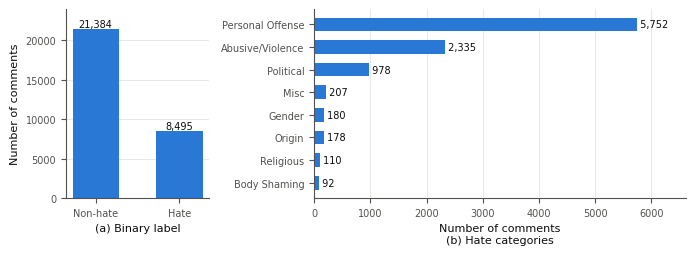

Saved: /content/drive/MyDrive/ML_Project/results/figures/fig_02_class_balance.png
Registered F02 -> figures/fig_02_class_balance.png


In [11]:
balance_rows = [
    {'Label': 'Non-hate (Label = 0)', **{s: int((df[HATE_COL] == 0).sum()) for s, df in splits.items()}},
    {'Label': 'Hate (Label = 1)', **{s: int((df[HATE_COL] == 1).sum()) for s, df in splits.items()}},
]
for col in TARGET_COLS:
    balance_rows.append({'Label': col, **{s: int(df[col].sum()) for s, df in splits.items()}})
balance_table = pd.DataFrame(balance_rows).rename(
    columns={'train': 'Train', 'validation': 'Validation', 'test': 'Test'})
balance_table['Train (%)'] = 100 * balance_table['Train'] / len(train_df)
display(balance_table)

save_table(balance_table, 'tab_02_class_balance')
register_asset('T02', 'tables/tab_02_class_balance.csv (+ .tex)',
               'Counts of binary labels and each of the 8 hate categories per split',
               NOTEBOOK_NAME, 'III. Dataset',
               'TABLE X. Label distribution in BanTH. Category counts can exceed the number of hate comments because a comment may carry several categories.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.6), gridspec_kw={'width_ratios': [1, 2.6]})

bin_counts = train_df[HATE_COL].value_counts().reindex([0, 1])
ax1.bar(['Non-hate', 'Hate'], bin_counts.values, color=BLUE, width=0.55)
for x, v in enumerate(bin_counts.values):
    ax1.text(x, v, f'{v:,}', ha='center', va='bottom', fontsize=7, color=INK)
ax1.set_ylabel('Number of comments')
ax1.set_xlabel('(a) Binary label')
ax1.set_ylim(0, bin_counts.max() * 1.12)
ax1.grid(axis='x', visible=False)

cat_counts = train_df[TARGET_COLS].sum().sort_values()
ax2.barh(cat_counts.index, cat_counts.values, color=BLUE, height=0.6)
for y, v in enumerate(cat_counts.values):
    ax2.text(v, y, f' {v:,}', va='center', fontsize=7, color=INK)
ax2.set_xlabel('Number of comments\n(b) Hate categories')
ax2.set_xlim(0, cat_counts.max() * 1.15)
ax2.grid(axis='y', visible=False)

fig.tight_layout()
fig_path = os.path.join(FIG_DIR, 'fig_02_class_balance.png')
fig.savefig(fig_path)
plt.show()
print('Saved:', fig_path)
register_asset('F02', 'figures/fig_02_class_balance.png',
               'Training-set counts: (a) hate vs non-hate, (b) each hate category',
               NOTEBOOK_NAME, 'III. Dataset',
               'Fig. X. Class distribution in the BanTH training split: (a) binary hate label and (b) the eight hate categories.')

## Comments with more than one category

The first table shows how many comments have 0, 1, 2 or more categories. The second shows how often two categories appear on the same comment in the training set. This is why we use a separate sigmoid output for each category instead of softmax.

In [12]:
max_k = int(max(df['num_categories'].max() for df in splits.values()))
overlap_table = pd.DataFrame({'Categories per comment': list(range(max_k + 1))})
for name, df in splits.items():
    counts = df['num_categories'].value_counts()
    overlap_table[name.capitalize()] = [int(counts.get(k, 0)) for k in range(max_k + 1)]
display(overlap_table)
save_table(overlap_table, 'tab_03_labels_per_comment')
register_asset('T03', 'tables/tab_03_labels_per_comment.csv (+ .tex)',
               'Number of comments with 0, 1, 2, ... hate categories per split',
               NOTEBOOK_NAME, 'III. Dataset',
               'TABLE X. Number of hate categories assigned per comment in each split.')

Y = train_df[TARGET_COLS].values
cooc = pd.DataFrame(Y.T @ Y, index=TARGET_COLS, columns=TARGET_COLS)
cooc_table = cooc.reset_index().rename(columns={'index': 'Category'})
display(cooc_table)
save_table(cooc_table, 'tab_04_category_cooccurrence')
register_asset('T04', 'tables/tab_04_category_cooccurrence.csv (+ .tex)',
               'Training-set co-occurrence counts between the 8 hate categories (diagonal = category total)',
               NOTEBOOK_NAME, 'III. Dataset',
               'TABLE X. Co-occurrence of hate categories in the BanTH training split. Diagonal entries give the total count of each category.')

,Categories per comment,Train,Validation,Test
0,0,21384,2674,2673
1,1,7246,913,892
2,2,1165,133,159
3,3,80,15,10
4,4,4,1,1


Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_03_labels_per_comment.csv
Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_03_labels_per_comment.tex
Registered T03 -> tables/tab_03_labels_per_comment.csv (+ .tex)


,Category,Political,Religious,Gender,Personal Offense,Abusive/Violence,Origin,Body Shaming,Misc
0,Political,978,24,3,395,109,14,1,10
1,Religious,24,110,6,38,10,7,1,2
2,Gender,3,6,180,119,36,5,9,1
3,Personal Offense,395,38,119,5752,486,46,44,25
4,Abusive/Violence,109,10,36,486,2335,8,6,5
5,Origin,14,7,5,46,8,178,5,14
6,Body Shaming,1,1,9,44,6,5,92,0
7,Misc,10,2,1,25,5,14,0,207


Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_04_category_cooccurrence.csv
Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_04_category_cooccurrence.tex
Registered T04 -> tables/tab_04_category_cooccurrence.csv (+ .tex)


## Comment length

Word count of each comment. This helps us choose the max length for the tokenizer in the training notebook. The histogram stops at the 99th percentile, because a few very long comments would squeeze the plot.

,Split,Mean,Median,95th pct.,99th pct.,Max
0,Train,10.169718,7.0,27.0,55.0,368
1,Validation,10.176927,7.0,28.0,54.0,225
2,Test,10.047925,7.0,27.0,48.0,187


Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_05_text_length_stats.csv
Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_05_text_length_stats.tex
Registered T05 -> tables/tab_05_text_length_stats.csv (+ .tex)


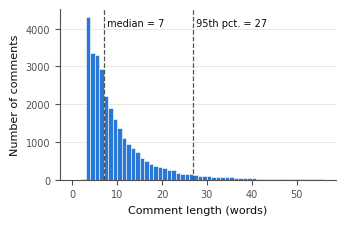

Saved: /content/drive/MyDrive/ML_Project/results/figures/fig_03_text_length.png
290 training comments longer than 55 words are not drawn (above the 99th percentile).
Registered F03 -> figures/fig_03_text_length.png


In [13]:
length_rows = []
for name, df in splits.items():
    df['word_count'] = df['clean_text'].str.split().str.len()
    wc = df['word_count']
    length_rows.append({'Split': name.capitalize(), 'Mean': wc.mean(), 'Median': wc.median(),
                        '95th pct.': wc.quantile(0.95), '99th pct.': wc.quantile(0.99),
                        'Max': int(wc.max())})
length_table = pd.DataFrame(length_rows)
display(length_table)
save_table(length_table, 'tab_05_text_length_stats', float_format='%.1f')
register_asset('T05', 'tables/tab_05_text_length_stats.csv (+ .tex)',
               'Comment length in words per split: mean, median, 95th and 99th percentile, max',
               NOTEBOOK_NAME, 'III. Dataset',
               'TABLE X. Comment length statistics (whitespace-separated words) for each split.')

wc = train_df['word_count']
p99 = int(np.ceil(wc.quantile(0.99)))
fig, ax = plt.subplots(figsize=(3.5, 2.3))
ax.hist(wc[wc <= p99], bins=range(0, p99 + 2), color=BLUE, edgecolor='white', linewidth=0.4)
for value, label in [(wc.median(), 'median'), (wc.quantile(0.95), '95th pct.')]:
    ax.axvline(value, color=MUTED, linestyle='--', linewidth=0.9)
    ax.text(value, ax.get_ylim()[1] * 0.95, f' {label} = {value:.0f}', fontsize=7, color=INK, va='top')
ax.set_xlabel('Comment length (words)')
ax.set_ylabel('Number of comments')
ax.grid(axis='x', visible=False)
fig.tight_layout()
fig_path = os.path.join(FIG_DIR, 'fig_03_text_length.png')
fig.savefig(fig_path)
plt.show()
print('Saved:', fig_path)
print(f'{(wc > p99).sum()} training comments longer than {p99} words are not drawn (above the 99th percentile).')
register_asset('F03', 'figures/fig_03_text_length.png',
               'Histogram of training comment lengths in words, cut at the 99th percentile',
               NOTEBOOK_NAME, 'III. Dataset',
               f'Fig. X. Distribution of comment length in the BanTH training split (words; comments above the 99th percentile, {p99} words, are omitted).')

## Example comments

2 non-hate and 3 hate comments picked randomly from the training set (seed 42). In the LaTeX version the text is shortened and emoji are removed, because LaTeX can't print emoji.

In [14]:
non_hate = train_df[train_df[HATE_COL] == 0].sample(2, random_state=SEED)
hate = train_df[train_df[HATE_COL] == 1].sample(3, random_state=SEED)
samples = pd.concat([non_hate, hate])

def categories_of(row):
    names = [c for c in TARGET_COLS if row[c] == 1]
    return ', '.join(names) if names else '-'

sample_table = pd.DataFrame({
    'ID': samples['comment_id'].values,
    'Text': samples['clean_text'].values,
    'English (dataset)': samples['english'].values,
    'Hate': samples[HATE_COL].values,
    'Categories': samples.apply(categories_of, axis=1).values,
})
display(sample_table)

def ascii_short(s, n=60):
    s = str(s).encode('ascii', 'ignore').decode()
    s = SPACE_RE.sub(' ', s).strip()
    return s if len(s) <= n else s[:n - 3].rstrip() + '...'

sample_tex = sample_table.copy()
for col in ['Text', 'English (dataset)']:
    sample_tex[col] = sample_tex[col].map(ascii_short)

save_table(sample_table, 'tab_06_sample_rows', tex_df=sample_tex)
register_asset('T06', 'tables/tab_06_sample_rows.csv (+ .tex)',
               'Five random training comments (2 non-hate, 3 hate; seed 42) with labels and categories',
               NOTEBOOK_NAME, 'III. Dataset',
               'TABLE X. Example comments from the BanTH training split with their English versions from the dataset and their labels (text shortened; emoji removed).')

,ID,Text,English (dataset),Hate,Categories
0,train_24478,Owo t 20,O T 20,0,-
1,train_22205,Tomr netri k ese khoma cayte bolo R jader jibon giyece ta age firiye daw,Tell your sister to come and apologize and return the lives that have gone.,0,-
2,train_29012,E sorerer bachha,This is everyone's home.,1,Personal Offense
3,train_16164,Bat par shomon,Bat Par Suman,1,"Political, Personal Offense"
4,train_05288,Ai pagol k nia ato ghata ghati koraw paglami chara r kisui na😡😡😡😡,You care so much about this crazy man is nothing but head.😡😡😡😡,1,Personal Offense


Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_06_sample_rows.csv
Saved: /content/drive/MyDrive/ML_Project/results/tables/tab_06_sample_rows.tex
Registered T06 -> tables/tab_06_sample_rows.csv (+ .tex)


## Save the cleaned data

The training notebook reads these files.

In [15]:
keep_cols = (['comment_id', TEXT_COL, 'clean_text', HATE_COL] + TARGET_COLS
             + ['bangla', 'english', 'num_categories', 'word_count'])
for name, df in splits.items():
    path = os.path.join(PROC_DIR, f'{name}.csv')
    df[keep_cols].to_csv(path, index=False, encoding='utf-8')
    print(f'Saved: {path}  ({len(df):,} rows)')

Saved: /content/drive/MyDrive/ML_Project/data/processed/train.csv  (29,879 rows)
Saved: /content/drive/MyDrive/ML_Project/data/processed/validation.csv  (3,736 rows)
Saved: /content/drive/MyDrive/ML_Project/data/processed/test.csv  (3,735 rows)


## Save all the numbers

Every number from this notebook is saved in metrics_data.json, so each number in the report comes from a saved file.

In [16]:
metrics = {
    'step': 'data',
    'notebook': NOTEBOOK_NAME,
    'dataset': 'aplycaebous/BanTH (HuggingFace), official splits',
    'date': datetime.now().isoformat(timespec='seconds'),
    'seed': SEED,
    'split_sizes': {n: len(df) for n, df in splits.items()},
    'hate_counts': {n: int(df[HATE_COL].sum()) for n, df in splits.items()},
    'category_counts': {n: {c: int(df[c].sum()) for c in TARGET_COLS} for n, df in splits.items()},
    'label_category_consistency': consistency,
    'cleaning': cleaning_stats,
    'duplicates': duplicate_stats,
    'word_length': {r['Split'].lower(): {k: float(v) for k, v in r.items() if k != 'Split'}
                    for r in length_rows},
}
metrics_path = os.path.join(REP_DIR, 'metrics_data.json')
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))
print('Saved:', metrics_path)
register_asset('M03', 'evaluation_reports/metrics_data.json',
               'All dataset statistics: sizes, label counts, consistency, cleaning, duplicates, lengths',
               NOTEBOOK_NAME, 'III. Dataset / VII. Limitations',
               'Not a figure; source file for every dataset number quoted in the text.')

{
  "step": "data",
  "notebook": "01_data_exploration.ipynb",
  "dataset": "aplycaebous/BanTH (HuggingFace), official splits",
  "date": "2026-09-28T06:23:38",
  "seed": 42,
  "split_sizes": {
    "train": 29879,
    "validation": 3736,
    "test": 3735
  },
  "hate_counts": {
    "train": 8495,
    "validation": 1062,
    "test": 1062
  },
  "category_counts": {
    "train": {
      "Political": 978,
      "Religious": 110,
      "Gender": 180,
      "Personal Offense": 5752,
      "Abusive/Violence": 2335,
      "Origin": 178,
      "Body Shaming": 92,
      "Misc": 207
    },
    "validation": {
      "Political": 111,
      "Religious": 22,
      "Gender": 24,
      "Personal Offense": 710,
      "Abusive/Violence": 293,
      "Origin": 26,
      "Body Shaming": 17,
      "Misc": 25
    },
    "test": {
      "Political": 117,
      "Religious": 18,
      "Gender": 23,
      "Personal Offense": 715,
      "Abusive/Violence": 304,
      "Origin": 23,
      "Body Shaming": 14,
     

## Summary

We loaded the official BanTH splits, checked the labels, cleaned the text (URLs and extra spaces only), and saved tables T01 to T06 and figures F02 and F03. The cleaned data is in data/processed/ and is used next by the training notebook.

## Remember this

- What we did: loaded the official BanTH splits, checked the labels, removed only URLs and extra spaces, and saved the dataset tables and charts.
- Why: the official splits keep our results comparable with the BanTH paper, and we kept spelling variation and emoji because that is how people really write transliterated Bangla.
- Key number: 29,879 / 3,736 / 3,735 comments (train / validation / test).